In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

from pathlib import Path


In [16]:
file_path = Path('../data/raw/online_retail_II.csv')
df = pd.read_csv(file_path)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [18]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [19]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [21]:
df = df.dropna(subset=["Customer ID"])

In [22]:
# Negative quantity = returns/cancellations
# For this project, we remove them.
df = df[df["Quantity"] > 0]

In [ ]:
# Remove negative/zero price
df = df[df["Price"] > 0]

In [25]:
# Removing duplicated
df = df.drop_duplicates()

In [ ]:
# Converting Date Column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [27]:
# Creating Revenue Column
df["Revenue"] = df["Quantity"] * df["Price"]

In [28]:
# Creating features for ML
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day

In [29]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [30]:
df.to_csv("../data/processed/cleaned_retail.csv", index=False)

In [31]:
df.shape

(779425, 12)

# EDA

In [ ]:
# Total Revenue
total_revenue = df["Revenue"].sum()
total_customers = df["Customer ID"].nunique()
total_orders = df["Invoice"].nunique()
avg_order_value = total_revenue / total_orders

total_revenue, total_customers, total_orders, avg_order_value

(np.float64(17374804.268000003), 5878, 36969, np.float64(469.9830741432011))

In [ ]:
# Monthly Revenue Trend
monthly_sales = df.groupby(["Year", "Month"])["Revenue"].sum().reset_index()

monthly_sales["YearMonth"] = monthly_sales["Year"].astype(str) + "-" + monthly_sales["Month"].astype(str)

monthly_sales

,Year,Month,Revenue,YearMonth
0,2009,12,683504.010,2009-12
1,2010,1,555802.672,2010-1
2,2010,2,504558.956,2010-2
3,2010,3,696978.471,2010-3
4,2010,4,591982.002,2010-4
5,2010,5,597833.380,2010-5
6,2010,6,636371.130,2010-6
7,2010,7,589736.170,2010-7
8,2010,8,602224.600,2010-8
9,2010,9,829013.951,2010-9


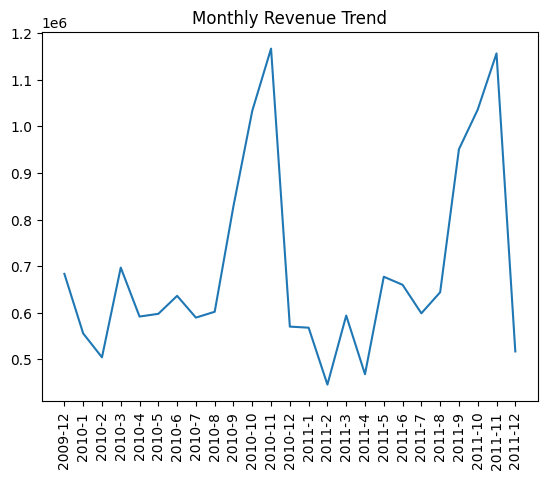

In [ ]:

plt.figure()
plt.plot(monthly_sales["YearMonth"], monthly_sales["Revenue"])
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.show()

Insight: There's a major spike in the winter months (Sep - Dec)

In [ ]:
# Revenue by Country
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

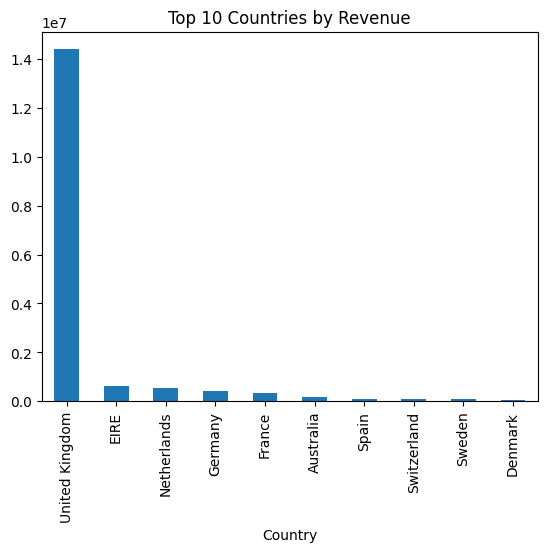

In [39]:
country_sales.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.show()

Insight: USA Dominating

In [ ]:
# Top 10 customers
top_customers = df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False)

top_customers.head(10)

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

In [ ]:
# Best Selling Products
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)

top_products.head(10)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: Revenue, dtype: float64

In [47]:
contribution_pct = (top_customers.head(10).sum() / total_revenue) * 100

print(f"Top 10 customers contribute: {contribution_pct:.2f}% of total revenue")

Top 10 customers contribute: 16.04% of total revenue


In [48]:
contribution_pct = (top_products.head(10).sum() / total_revenue) * 100

print(f"Top 10 products contribute: {contribution_pct:.2f}% of total revenue")

Top 10 products contribute: 8.57% of total revenue


# ML

In [50]:
customer_df = df.groupby("Customer ID").agg({
    "Revenue": "sum",
    "Invoice": "nunique",
    "Quantity": "sum"
}).reset_index()

customer_df.columns = ["CustomerID", "TotalSpent", "TotalOrders", "TotalQuantity"]

customer_df.head()

,CustomerID,TotalSpent,TotalOrders,TotalQuantity
0,12346.0,77556.46,12,74285
1,12347.0,4921.53,8,2967
2,12348.0,2019.40,5,2714
3,12349.0,4428.69,4,1624
4,12350.0,334.40,1,197


In [52]:
X = customer_df[["TotalOrders", "TotalQuantity"]]
y = customer_df["TotalSpent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

r2, mae

(0.9398668019703643, 787.022494483863)

In [55]:
customer_df["TotalSpent"].mean()

np.float64(2955.9040945899965)

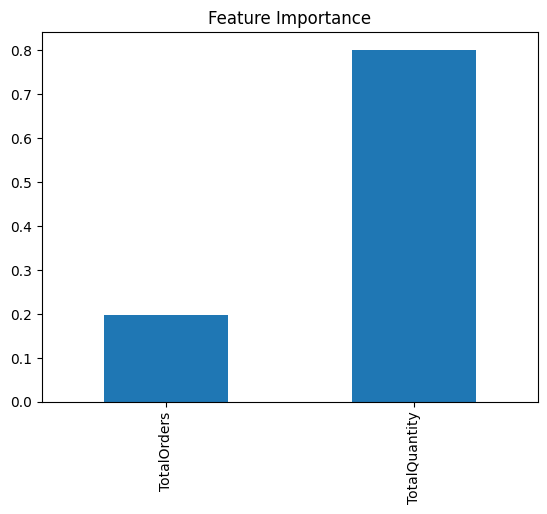

In [56]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()